### Embedding layer diagram

BERT-large embedding stage for one example sentence: tokenize, look up ids,
token embeddings + positional encoding, then LayerNorm + dropout. The output
X (6 x 1024) is the encoder input in the encoder layer figure.

Writes `embedding_diagram.png`.

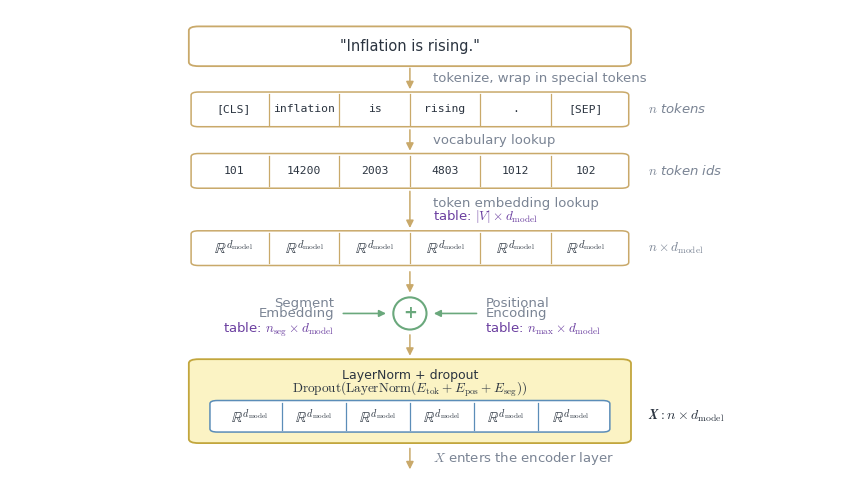

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Ellipse

INK = "#2b3440"
SAND_E = "#c9a96a"
BLUE_E = "#5b8db8"
GREEN_E = "#6aa87c"
YEL, YEL_E = "#fbf3c4", "#c2a63d"
GREYT = "#7a8494"
TRAIN = "#6b3fa0"

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.set_xlim(0, 11.0)
ax.set_ylim(29.2, 44.1)
ax.axis("off")

X, W = 2.5, 5.6
MID = X + W / 2
NX = X + W + 0.35  # left edge of the side-note column, hugging the boxes

MATHR = r"$\mathbb{R}^{d_{\mathrm{model}}}$"
NDIM = r"$n \times d_{\mathrm{model}}$"
XLBL = r"$\boldsymbol{X}: n \times d_{\mathrm{model}}$"
EMBEQ = r"$\mathrm{Dropout}(\mathrm{LayerNorm}(E_{\mathrm{tok}} + E_{\mathrm{pos}} + E_{\mathrm{seg}}))$"
TOKTBL = r"table: $|V| \times d_{\mathrm{model}}$"
POSTBL = r"table: $n_{\max} \times d_{\mathrm{model}}$"
SEGTBL = r"table: $n_{\mathrm{seg}} \times d_{\mathrm{model}}$"


def box(x, y, w, h, text, fc, ec, fs=9, lw=1.3):
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.13",
            facecolor=fc,
            edgecolor=ec,
            linewidth=lw,
        )
    )
    if text:
        ax.text(
            x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=INK
        )


def dim(x, y, text):
    ax.text(
        x, y, text, ha="left", va="center", fontsize=9.5, style="italic", color=GREYT
    )


def note(y, text, fs=9.5):
    ax.text(MID + 0.3, y, text, fontsize=fs, color=GREYT, ha="left", va="center")


def arrow(y0, c=INK, x=None, dy=0.84):
    if x is None:
        x = MID
    ax.add_patch(
        FancyArrowPatch(
            (x, y0), (x, y0 - dy), arrowstyle="-|>", mutation_scale=11, color=c, lw=1.1
        )
    )


def table_row(y, labels, fs=8.2, fc="white", ec=SAND_E, h=0.9, x=None, w=None):
    if x is None:
        x = X
    if w is None:
        w = W
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle="round,pad=0.10",
            facecolor=fc,
            edgecolor=ec,
            linewidth=1.1,
        )
    )
    n = len(labels)
    for i, t in enumerate(labels):
        if i:
            ax.plot(
                [x + i * w / n, x + i * w / n],
                [y - 0.03, y + h + 0.03],
                color=ec,
                lw=0.9,
            )
        ax.text(
            x + (i + 0.5) * w / n,
            y + h / 2,
            t,
            ha="center",
            va="center",
            fontsize=fs,
            family="DejaVu Sans Mono",
            color=INK,
        )


box(X, 42.45, W, 1.0, '"Inflation is rising."', "white", SAND_E, fs=10.5)
arrow(42.34, SAND_E)
note(41.92, "tokenize, wrap in special tokens")

table_row(40.5, ["[CLS]", "inflation", "is", "rising", ".", "[SEP]"])
dim(NX, 40.95, "$n$ tokens")
arrow(40.39, SAND_E)
note(39.97, "vocabulary lookup")

table_row(38.55, ["101", "14200", "2003", "4803", "1012", "102"])
dim(NX, 39.0, "$n$ token ids")
arrow(38.44, SAND_E, dy=1.34)
ax.text(
    MID + 0.3,
    37.98,
    "token embedding lookup",
    fontsize=9.5,
    color=GREYT,
    ha="left",
    va="center",
)
ax.text(MID + 0.3, 37.56, TOKTBL, fontsize=9.5, color=TRAIN, ha="left", va="center")

table_row(36.1, [MATHR] * 6, fs=11.0)
dim(NX, 36.55, NDIM)
arrow(35.89, SAND_E)

# summing node: token + positional + segment embeddings
ax.add_patch(
    Ellipse((MID, 34.48), 0.44, 1.02, facecolor="white", edgecolor=GREEN_E, lw=1.5)
)
ax.text(
    MID,
    34.48,
    "+",
    ha="center",
    va="center",
    fontsize=12,
    color=GREEN_E,
    fontweight="bold",
)

ax.text(MID + 1.0, 34.70, "Positional", fontsize=9.5, color=GREYT, ha="left")
ax.text(MID + 1.0, 34.38, "Encoding", fontsize=9.5, color=GREYT, ha="left")
ax.text(MID + 1.0, 33.88, POSTBL, fontsize=9.5, color=TRAIN, ha="left")
ax.add_patch(
    FancyArrowPatch(
        (MID + 0.92, 34.48),
        (MID + 0.28, 34.48),
        arrowstyle="-|>",
        mutation_scale=10,
        color=GREEN_E,
        lw=1.2,
    )
)

ax.text(MID - 1.0, 34.70, "Segment", fontsize=9.5, color=GREYT, ha="right")
ax.text(MID - 1.0, 34.38, "Embedding", fontsize=9.5, color=GREYT, ha="right")
ax.text(MID - 1.0, 33.88, SEGTBL, fontsize=9.5, color=TRAIN, ha="right")
ax.add_patch(
    FancyArrowPatch(
        (MID - 0.92, 34.48),
        (MID - 0.28, 34.48),
        arrowstyle="-|>",
        mutation_scale=10,
        color=GREEN_E,
        lw=1.2,
    )
)
arrow(33.89, SAND_E)

# LayerNorm + dropout; the resulting X is the encoder input
box(X, 30.5, W, 2.4, "", YEL, YEL_E)
ax.text(
    MID, 32.52, "LayerNorm + dropout", ha="center", va="center", fontsize=9, color=INK
)
ax.text(MID, 32.08, EMBEQ, ha="center", va="center", fontsize=9.5, color=INK)
table_row(30.82, [MATHR] * 6, fs=10.5, ec=BLUE_E, h=0.8, x=X + 0.25, w=W - 0.5)
ax.text(NX, 31.22, XLBL, ha="left", va="center", fontsize=10, color=INK)
arrow(30.29, SAND_E)
note(29.87, "$X$ enters the encoder layer")

fig.tight_layout()
fig.savefig("embedding_diagram.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig("embedding_diagram.pdf", bbox_inches="tight", facecolor="white")